## Домашнее задание 2


В этом домашнем задании мы закрепим основные концепты, которые прошли во втором модуле.

Представьте, что вы работаете дата-аналитиком в крупном инвестфонде. Вам дали данные по выручке и стоимости акций крупных компаний за 2019—2024 гг. А также предоставили динамику изменения стоимости самых популярных полезных ископаемых. Ваша задача — провести первичный анализ имеющихся данных и сделать ряд выводов относительно роста различных компаний, а также целесообразности инвестиций в них.

Подробнее со структурой датасета можно познакомиться [по ссылке](https://www.kaggle.com/datasets/saketk511/2019-2024-us-stock-market-data).

Не забывайте, что каждый построенный вами график должен иметь законченный вид: должны быть подписаны оси, добавлено релевантное название. Там, где это нужно, стоит добавить легенду.

In [109]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [110]:
# Импортируем все библиотеки, которые будем использовать в рамках работы
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import missingno as msno
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go

In [111]:
stock_market = pd.read_csv("https://raw.githubusercontent.com/ElijahSum/mipt_visualization/master/week_02_visualization/stock_market_data.csv", index_col=0)
stock_market.head()

,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
0,02-02-2024,2.079,NaN,72.28,NaN,3.8215,NaN,"43,194.70",42650.0,901.6,...,"5,89,498",10580.0,564.64,4030000.0,171.81,117220000.0,474.99,84710000.0,"2,053.70",NaN
1,01-02-2024,2.050,161340.0,73.82,577940.0,3.8535,NaN,"43,081.40",47690.0,922.3,...,"5,81,600",9780.0,567.51,3150000.0,159.28,66360000.0,394.78,25140000.0,"2,071.10",260920.0
2,31-01-2024,2.100,142860.0,75.85,344490.0,3.9060,NaN,"42,580.50",56480.0,932.6,...,"5,78,020",9720.0,564.11,4830000.0,155.20,49690000.0,390.14,20010000.0,"2,067.40",238370.0
3,30-01-2024,2.077,139750.0,77.82,347240.0,3.9110,NaN,"42,946.20",55130.0,931.7,...,"5,84,680",9750.0,562.85,6120000.0,159.00,42290000.0,400.06,18610000.0,"2,050.90",214590.0
4,29-01-2024,2.490,3590.0,76.78,331930.0,3.8790,NaN,"43,299.80",45230.0,938.3,...,"5,78,800",13850.0,575.79,6880000.0,161.26,42840000.0,401.02,17790000.0,"2,034.90",1780.0


In [112]:
stock_market.columns.unique()

Index(['Date', 'Natural_Gas_Price', 'Natural_Gas_Vol.', 'Crude_oil_Price',
       'Crude_oil_Vol.', 'Copper_Price', 'Copper_Vol.', 'Bitcoin_Price',
       'Bitcoin_Vol.', 'Platinum_Price', 'Platinum_Vol.', 'Ethereum_Price',
       'Ethereum_Vol.', 'S&P_500_Price', 'Nasdaq_100_Price', 'Nasdaq_100_Vol.',
       'Apple_Price', 'Apple_Vol.', 'Tesla_Price', 'Tesla_Vol.',
       'Microsoft_Price', 'Microsoft_Vol.', 'Silver_Price', 'Silver_Vol.',
       'Google_Price', 'Google_Vol.', 'Nvidia_Price', 'Nvidia_Vol.',
       'Berkshire_Price', 'Berkshire_Vol.', 'Netflix_Price', 'Netflix_Vol.',
       'Amazon_Price', 'Amazon_Vol.', 'Meta_Price', 'Meta_Vol.', 'Gold_Price',
       'Gold_Vol.'],
      dtype='object')

## Задание 1 (3 балла)

Посмотрите текущий тип данных столбца с датами. Преобразуйте тип данных в формат `pandas.Timestamp`.

С помощью функционала библиотеки `Pandas` создайте линейные графики динамики стоимости Bitcoin и Ethereum с января 2019 года по декабрь 2021 года.

In [113]:
stock_market.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1243 entries, 0 to 1242
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1243 non-null   object 
 1   Natural_Gas_Price  1243 non-null   float64
 2   Natural_Gas_Vol.   1239 non-null   float64
 3   Crude_oil_Price    1243 non-null   float64
 4   Crude_oil_Vol.     1220 non-null   float64
 5   Copper_Price       1243 non-null   float64
 6   Copper_Vol.        1206 non-null   float64
 7   Bitcoin_Price      1243 non-null   object 
 8   Bitcoin_Vol.       1243 non-null   float64
 9   Platinum_Price     1243 non-null   object 
 10  Platinum_Vol.      636 non-null    float64
 11  Ethereum_Price     1243 non-null   object 
 12  Ethereum_Vol.      1243 non-null   float64
 13  S&P_500_Price      1243 non-null   object 
 14  Nasdaq_100_Price   1243 non-null   object 
 15  Nasdaq_100_Vol.    1242 non-null   float64
 16  Apple_Price        1243 non-n

In [114]:
stock_market['Date'] = pd.to_datetime(stock_market['Date'], format='%d-%m-%Y', dayfirst=True)

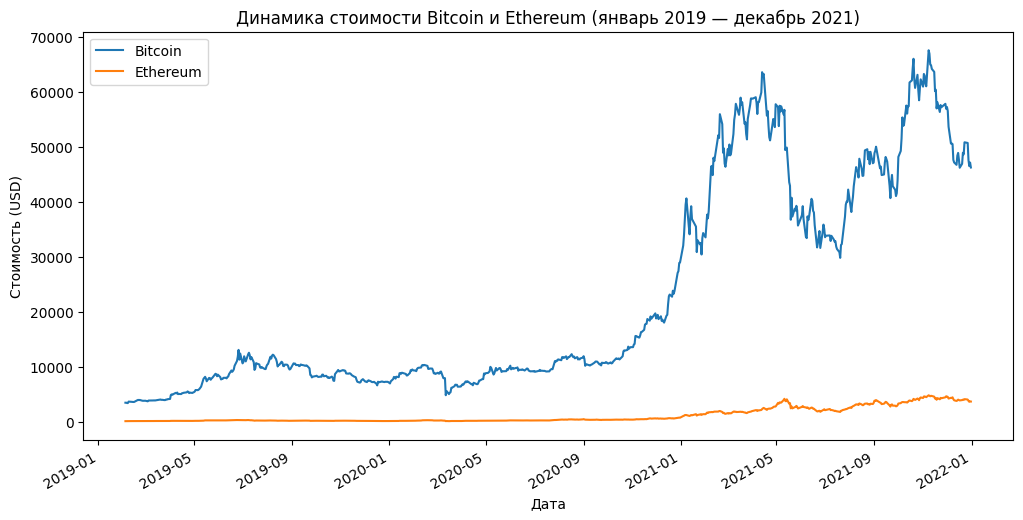

In [115]:
for col in ['Bitcoin_Price', 'Ethereum_Price']:
    stock_market[col] = pd.to_numeric(stock_market[col].astype(str).str.replace(',', ''), errors='coerce')

mask = (stock_market['Date'] >= '2019-01-01') & (stock_market['Date'] <= '2021-12-31')
crypto_period = stock_market.loc[mask, ['Date', 'Bitcoin_Price', 'Ethereum_Price']].copy()

ax = crypto_period.set_index('Date')[['Bitcoin_Price', 'Ethereum_Price']].plot(
    kind='line',
    figsize=(12, 6),
    title='Динамика стоимости Bitcoin и Ethereum (январь 2019 — декабрь 2021)',
    xlabel='Дата',
    ylabel='Стоимость (USD)',
    legend=True
)
ax.legend(['Bitcoin', 'Ethereum']);

## Задание 2 (2 балла)

Создайте один график, на котором будет изображена динамика цен на все полезные ископаемые в 2019—2024 гг. (`Natural Gas`, `Crude Oil`, `Copper`, `Platinum`, `Gold`). Цены рассчитайте относительно 4 февраля 2019 года (Цены в этот день возьмите за 1, остальные цены рассчитайте как отношение цены в заданный день к цене 4 февраля 2019 года).

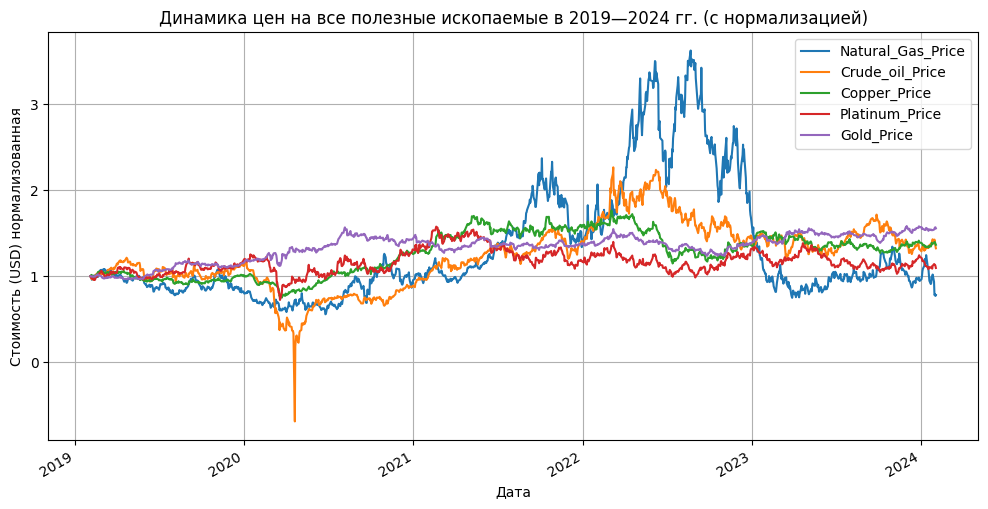

In [116]:
for col in ['Natural_Gas_Price', 'Crude_oil_Price', 'Copper_Price', 'Platinum_Price', 'Gold_Price']:
    if stock_market[col].dtype == 'object':
        stock_market[col] = pd.to_numeric(stock_market[col].astype(str).str.replace(',', ''), errors = 'coerce')

mask = (stock_market['Date']>= '2019-01-01') & (stock_market['Date']<= '2025-01-01')
minerals = stock_market.loc[mask, ['Date', 'Natural_Gas_Price', 'Crude_oil_Price', 'Copper_Price', 'Platinum_Price', 'Gold_Price']].copy()

base_date = '2019-02-04'

minerals_norm = minerals.copy()
minerals_norm = minerals_norm.set_index('Date')
minerals_norm = minerals_norm / minerals_norm.loc[base_date]

ax = minerals_norm.plot(
    kind = 'line',
    figsize = (12, 6),
    title = 'Динамика цен на все полезные ископаемые в 2019—2024 гг. (с нормализацией)',
    xlabel = 'Дата',
    ylabel='Стоимость (USD) нормализованная',
    legend=True,
)
ax.grid(True)
ax.legend(['Natural_Gas_Price', 'Crude_oil_Price', 'Copper_Price', 'Platinum_Price', 'Gold_Price']);

## Задание 3 (6 баллов)
Среди всех IT-компаний явно выделяются пять наиболее крупных компаний, которые объединены аббревиатурой `FAANG` (`Meta* (Former Facebook)`, `Amazon`, `Apple`, `Netflix`, `Google`). Многие программисты считают пиком возможной карьеры попадание именно в эти компании, а инвесторы пристально следят за деятельностью данных компаний. Давайте узнаем, насколько это оправданно.

**Признана экстремистской и запрещена на территории РФ*

**Задание 3.1**

Создайте функцию, которая будет принимать на вход произвольное количество столбцов формата `pandas.Series` и возвращать сумму этих серий.

Подсказка: используйте инструментарий [\*args и \**kwags](https://book.pythontips.com/en/latest/args_and_kwargs.html).

С помощью метода `.apply()` создайте новый столбец `FAANG`, который будет представлять собой сумму стоимости акций всех компаний, входящих в это символическое объединение.

In [117]:
faang_cols = ['Meta_Price', 'Amazon_Price', 'Apple_Price', 'Netflix_Price', 'Google_Price']

for col in faang_cols:
    if stock_market[col].dtype == 'object':
        stock_market[col] = pd.to_numeric(stock_market[col].astype(str).str.replace(',', ''), errors = 'coerce')

def FAANG(*args):
    result = 0
    for series in args:
        result += series
    return result

stock_market['FAANG'] = FAANG(
    stock_market['Meta_Price'],
    stock_market['Apple_Price'],
    stock_market['Netflix_Price'],
    stock_market['Amazon_Price'],
    stock_market['Google_Price'],
)
   
stock_market.head(5)

,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,...,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.,FAANG
0,2024-02-02,2.079,NaN,72.28,NaN,3.8215,NaN,43194.7,42650.0,901.6,...,10580.0,564.64,4030000.0,171.81,117220000.0,474.99,84710000.0,2053.7,NaN,1539.67
1,2024-02-01,2.050,161340.0,73.82,577940.0,3.8535,NaN,43081.4,47690.0,922.3,...,9780.0,567.51,3150000.0,159.28,66360000.0,394.78,25140000.0,2071.1,260920.0,1449.59
2,2024-01-31,2.100,142860.0,75.85,344490.0,3.9060,NaN,42580.5,56480.0,932.6,...,9720.0,564.11,4830000.0,155.20,49690000.0,390.14,20010000.0,2067.4,238370.0,1433.95
3,2024-01-30,2.077,139750.0,77.82,347240.0,3.9110,NaN,42946.2,55130.0,931.7,...,9750.0,562.85,6120000.0,159.00,42290000.0,400.06,18610000.0,2050.9,214590.0,1461.41
4,2024-01-29,2.490,3590.0,76.78,331930.0,3.8790,NaN,43299.8,45230.0,938.3,...,13850.0,575.79,6880000.0,161.26,42840000.0,401.02,17790000.0,2034.9,1780.0,1483.31


**Задание 3.2**

Аналогично с заданием 3 рассчитайте все стоимости акций компаний относительно стоимости 4 февраля 2019 года (возьмите это значение за единицу, остальные рассчитайте как соотношение). Создайте линейный график, на котором будут изображены все графики роста стоимости компаний (входящих в FAANG) относительно 4 февраля 2019 года. Также нанесите на график темпы роста всего FAANG. Те компании, которые росли быстрее (большую часть времени), чем в среднем росли показатели по FAANG, покрасьте в оттенки синего. А те компании, которые росли медленнее, покрасьте в оттенки красного.

Добавьте легенду и все остальные аттрибуты.

In [118]:
base_faang = stock_market.loc[stock_market['Date'] == base_date, 'FAANG'].iloc[0]
stock_market['FAANG_norm'] = stock_market['FAANG'] / base_faang

stock_market.head(5)

,Date,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,...,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.,FAANG,FAANG_norm
0,2024-02-02,2.079,NaN,72.28,NaN,3.8215,NaN,43194.7,42650.0,901.6,...,564.64,4030000.0,171.81,117220000.0,474.99,84710000.0,2053.7,NaN,1539.67,2.192825
1,2024-02-01,2.050,161340.0,73.82,577940.0,3.8535,NaN,43081.4,47690.0,922.3,...,567.51,3150000.0,159.28,66360000.0,394.78,25140000.0,2071.1,260920.0,1449.59,2.064531
2,2024-01-31,2.100,142860.0,75.85,344490.0,3.9060,NaN,42580.5,56480.0,932.6,...,564.11,4830000.0,155.20,49690000.0,390.14,20010000.0,2067.4,238370.0,1433.95,2.042257
3,2024-01-30,2.077,139750.0,77.82,347240.0,3.9110,NaN,42946.2,55130.0,931.7,...,562.85,6120000.0,159.00,42290000.0,400.06,18610000.0,2050.9,214590.0,1461.41,2.081366
4,2024-01-29,2.490,3590.0,76.78,331930.0,3.8790,NaN,43299.8,45230.0,938.3,...,575.79,6880000.0,161.26,42840000.0,401.02,17790000.0,2034.9,1780.0,1483.31,2.112556


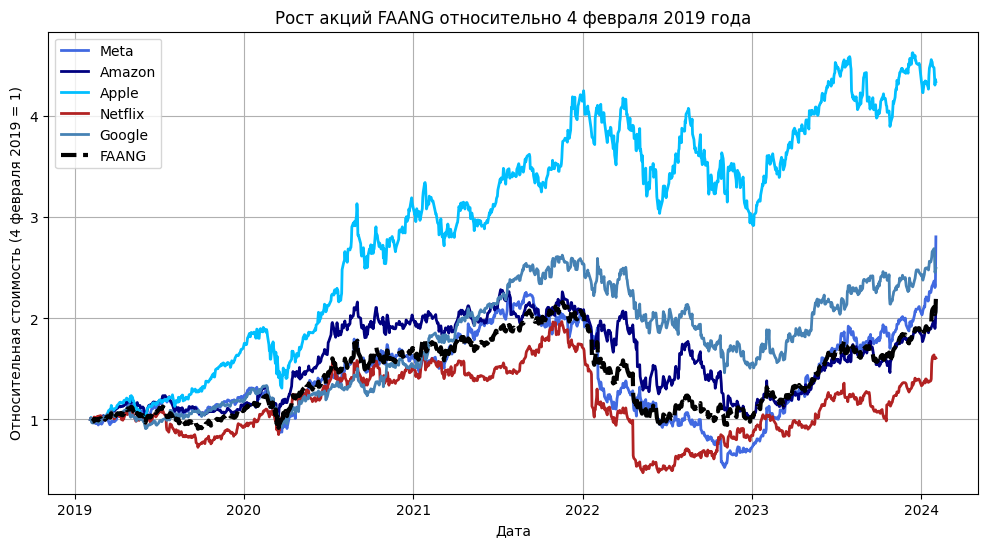

In [119]:
for col in faang_cols:
    base_value = stock_market.loc[stock_market['Date'] == base_date, col].iloc[0]
    stock_market[col + '_norm'] = stock_market[col] / base_value

fast_companies = []
slow_companies = []

for col in faang_cols:
    norm_col = col + '_norm'
    if (stock_market[norm_col] > stock_market['FAANG_norm']).sum() > len(stock_market) / 2:
        fast_companies.append(col)
    else:
        slow_companies.append(col)

blue_shades = ['royalblue', 'navy', 'deepskyblue', 'steelblue', 'cornflowerblue']
red_shades = ['firebrick', 'indianred', 'tomato', 'salmon', 'darkred']

color_map = {}

for i, col in enumerate(fast_companies):
    color_map[col] = blue_shades[i % len(blue_shades)]

for i, col in enumerate(slow_companies):
    color_map[col] = red_shades[i % len(red_shades)]

fig, ax = plt.subplots(figsize=(12, 6))

for col in faang_cols:
    ax.plot(
        stock_market['Date'],
        stock_market[col + '_norm'],
        label=col.replace('_Price', ''),
        color=color_map[col],
        linewidth=2
    )

ax.plot(
    stock_market['Date'],
    stock_market['FAANG_norm'],
    label='FAANG',
    color='black',
    linestyle='--',
    linewidth=3
)

ax.set_title('Рост акций FAANG относительно 4 февраля 2019 года')
ax.set_xlabel('Дата')
ax.set_ylabel('Относительная стоимость (4 февраля 2019 = 1)')
ax.legend()
ax.grid(True)

plt.show()   

**Задание 3.3**

Что выгоднее — инвестиции в полезные ископаемые или в крупные компании?

Создайте линейный график с двумя линиями.
Первая линия будет отвечать за полезные ископаемые. Рассчитайте стоимость всех полезных ископаемых в ценах относительно 4 февраля 2019 года. Возьмите это значение за 1, остальные цены получите как отношение к этой цене. Например, если за месяц цены выросли на 10%, то полученное значение будет равно 1.1.
Подсчитайте среднее по всем полезным ископаемым по дням и добавьте получившиеся значения на график.

Аналогичную процедуру проведите для всех компаний в датасете. Получившийся средний рост стоимости акций добавьте на график.

In [120]:
minerals_cols = ['Natural_Gas_Price', 'Crude_oil_Price', 'Copper_Price', 'Platinum_Price', 'Gold_Price']

companies_cols = []
for col in stock_market.columns:
    if '_Price' in col and '_norm' not in col and col not in minerals_cols:
        companies_cols.append(col)

display(companies_cols)

for col in companies_cols:
    if stock_market[col].dtype == 'object':
        stock_market[col] = pd.to_numeric(stock_market[col].astype(str).str.replace(',', ''), errors = 'coerce')


['Bitcoin_Price',
 'Ethereum_Price',
 'S&P_500_Price',
 'Nasdaq_100_Price',
 'Apple_Price',
 'Tesla_Price',
 'Microsoft_Price',
 'Silver_Price',
 'Google_Price',
 'Nvidia_Price',
 'Berkshire_Price',
 'Netflix_Price',
 'Amazon_Price',
 'Meta_Price']

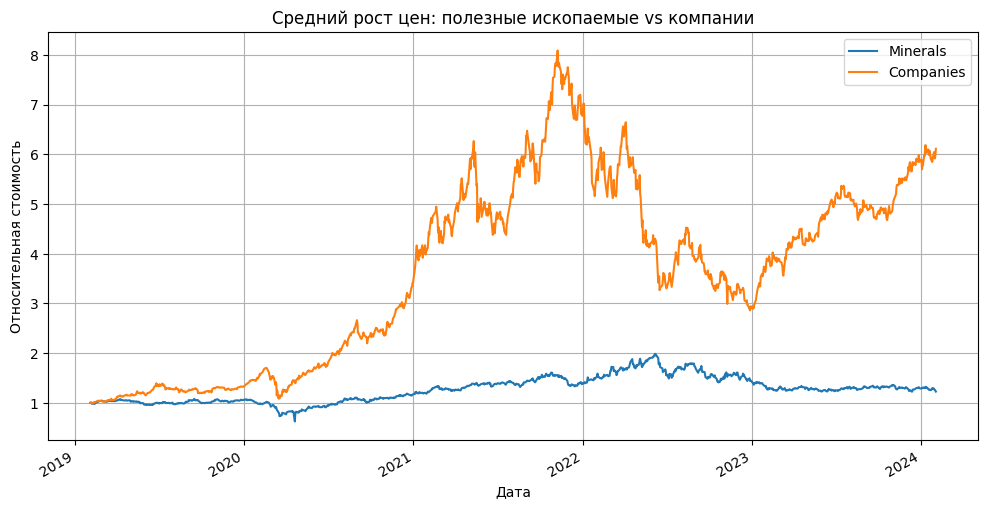

In [121]:
minerals_norm = stock_market[minerals_cols] / stock_market.loc[stock_market['Date'] == base_date, minerals_cols].iloc[0]
companies_norm = stock_market[companies_cols] / stock_market.loc[stock_market['Date'] == base_date, companies_cols].iloc[0]

minerals_mean = minerals_norm.mean(axis=1)
companies_mean = companies_norm.mean(axis=1)

plot_df = pd.DataFrame({
    'Date': stock_market['Date'],
    'Minerals': minerals_mean,
    'Companies': companies_mean
}).set_index('Date')

ax = plot_df.plot(
    figsize=(12, 6),
    title='Средний рост цен: полезные ископаемые vs компании',
    xlabel='Дата',
    ylabel='Относительная стоимость'
)

ax.legend()
ax.grid(True)

На основании полученных результатов ответьте на следующий вопрос: **Во что лучше инвестировать — полезные ископаемые или акции компаний?**

**Ваш ответ:** Лучше инвестировать в акции компаний, так как их средний рост за рассматриваемый период значительно выше, чем у полезных ископаемых.

## Задание 4 (6 баллов)
Давайте попробуем использовать разные подходы для реализации одной задачи — визуализации волатильности акций разных компаний.

**Задание 4.1**

С помощью библиотек `matplotlib` и `seaborn` создайте поле (`plt.subplots()`), в котором на графиках для каждой компании будет изображена динамика роста стоимости акций. Отметьте зеленым все компании, стоимость акций которых была в два раза выше на начало 2024 года в сравнении с ценой в начале 2019 года.

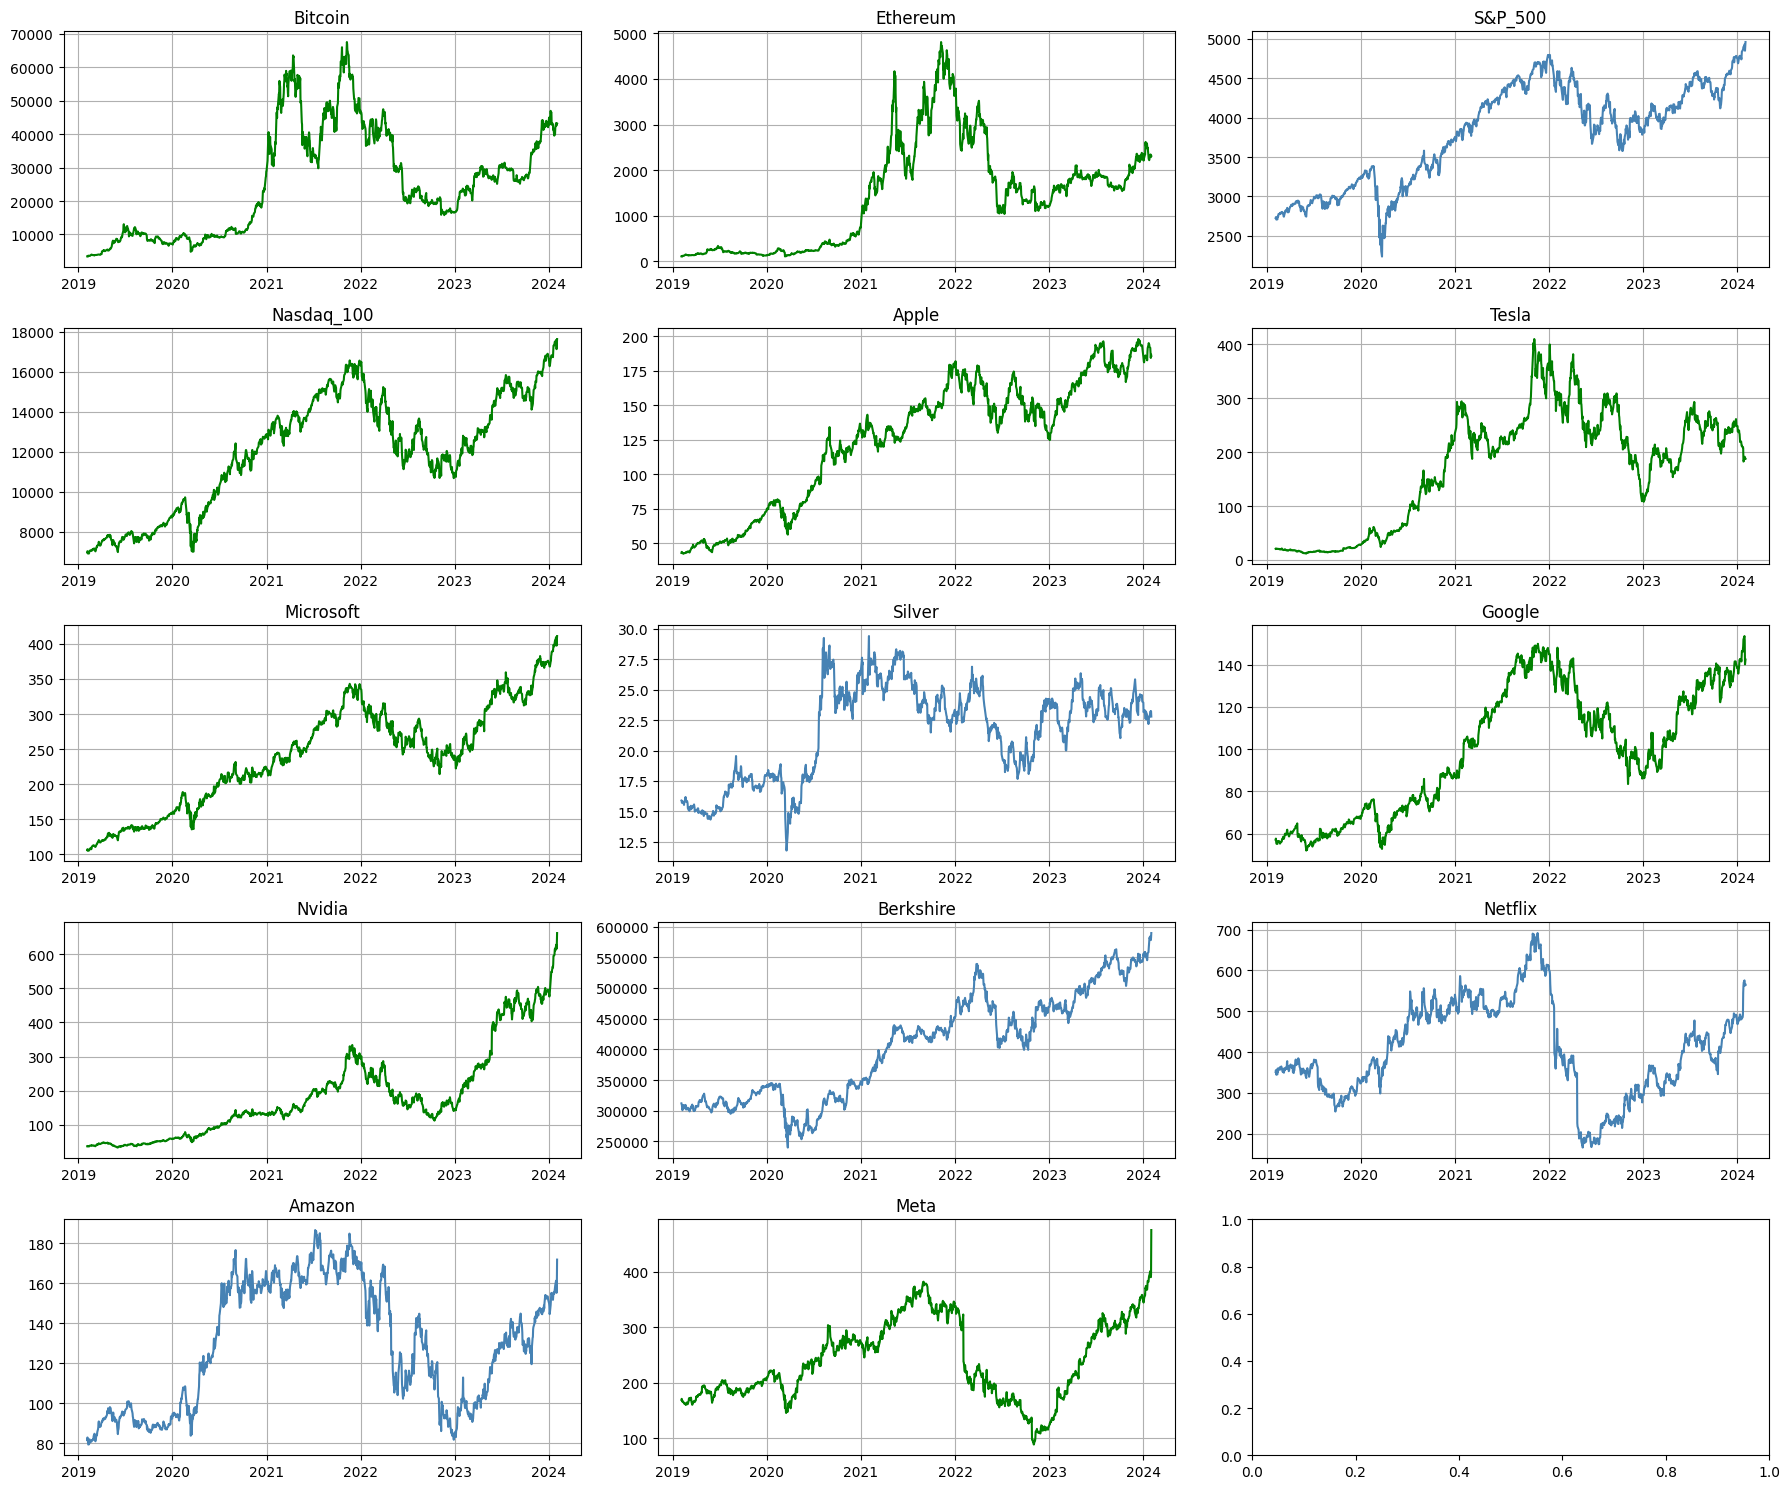

In [122]:
start_2019 = stock_market[stock_market['Date'].dt.year == 2019].iloc[0]
start_2024 = stock_market[stock_market['Date'].dt.year == 2024].iloc[0]

fig, axes = plt.subplots(5, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(companies_cols):

    start_price = start_2019[col]
    end_price = start_2024[col]

    if end_price >= 2 * start_price:
        color = 'green'
    else:
        color = 'steelblue'

    axes[i].plot(stock_market['Date'], stock_market[col], color=color)
    axes[i].set_title(col.replace('_Price', ''))
    axes[i].grid(True)

plt.tight_layout()
plt.show()

**Задание 4.2**

С помощью библиотеки `plotly` создайте `lineplot`, в котором будет изображена динамика акций компаний за период с 2019 по 2024 г. Добавьте на график кнопки для каждой компании, нажав на которые можно было бы переключиться между визуализациями динамики изменения стоимости акций для разных компаний.

Добавьте название и подписи к осям каждого графика.

In [123]:
fig = go.Figure()

for i, col in enumerate(companies_cols):
    fig.add_trace(
        go.Scatter(
            x=stock_market['Date'],
            y=stock_market[col],
            mode='lines',
            name=col.replace('_Price',''),
            visible=(i == 0)  
        )
    )

buttons = []

for i, col in enumerate(companies_cols):
    visibility = [False] * len(companies_cols)
    visibility[i] = True

    buttons.append(
        dict(
            label=col.replace('_Price',''),
            method="update",
            args=[{"visible": visibility},
                  {"title": f"Динамика акций: {col.replace('_Price','')}"}]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True
        )
    ],
    title="Динамика стоимости акций компаний (2019–2024)",
    xaxis_title="Дата",
    yaxis_title="Стоимость акции"
)

fig.show()

## Задание 5 (3 балла)
1. Напишите функцию, которая будет принимать на вход название компании и с помощью этого названия строить `scatter plot` с зависимостью цены (`Price`) акций от оборота (`Volume`) компании.
2. На каждый `scatter plot` добавьте линию линейной регрессии, которая будет показывать получившуюся зависимость. Получившуюся линию покрасьте в красный цвет.
3. Также на `scatter plot` добавьте текст с получившимся уравнением (вида $y = \beta_{0} + \beta_{1} X $).
4. Постройте поле (`plt.subplots()`) в котором будут изображены диаграммы рассеяния для всех компаний, присутствующих в датасете (используйте метод `.pipe()`). Каждая диаграмма рассеяния должна представлять собой зависимость цен на акции от выручки, иметь линию регрессии, а также текст с регрессионным уравнением для конкретной компании.

In [124]:
def plot_company_regression(df, company, ax=None):
    price_col = f'{company}_Price'
    vol_col = f'{company}_Vol.'

    if price_col not in df.columns or vol_col not in df.columns:
        ax.set_visible(False)
        return

    temp = df[[price_col, vol_col]].copy()
    temp[price_col] = pd.to_numeric(temp[price_col], errors='coerce')
    temp[vol_col] = pd.to_numeric(temp[vol_col], errors='coerce')

    temp = temp.dropna()

    if len(temp) < 2:
        ax.set_visible(False)
        return

    x = temp[vol_col]
    y = temp[price_col]

    sns.scatterplot(x=x, y=y, ax=ax)

    b1, b0 = np.polyfit(x, y, 1)
    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = b1 * x_vals + b0
    ax.plot(x_vals, y_vals, color='red')

    equation = f'y = {b0:.2f} + {b1:.6f}X'
    ax.text(
        0.05,
        0.95,
        equation,
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

    ax.set_title(company)
    ax.set_xlabel('Volume')
    ax.set_ylabel('Price')
    ax.grid(True)

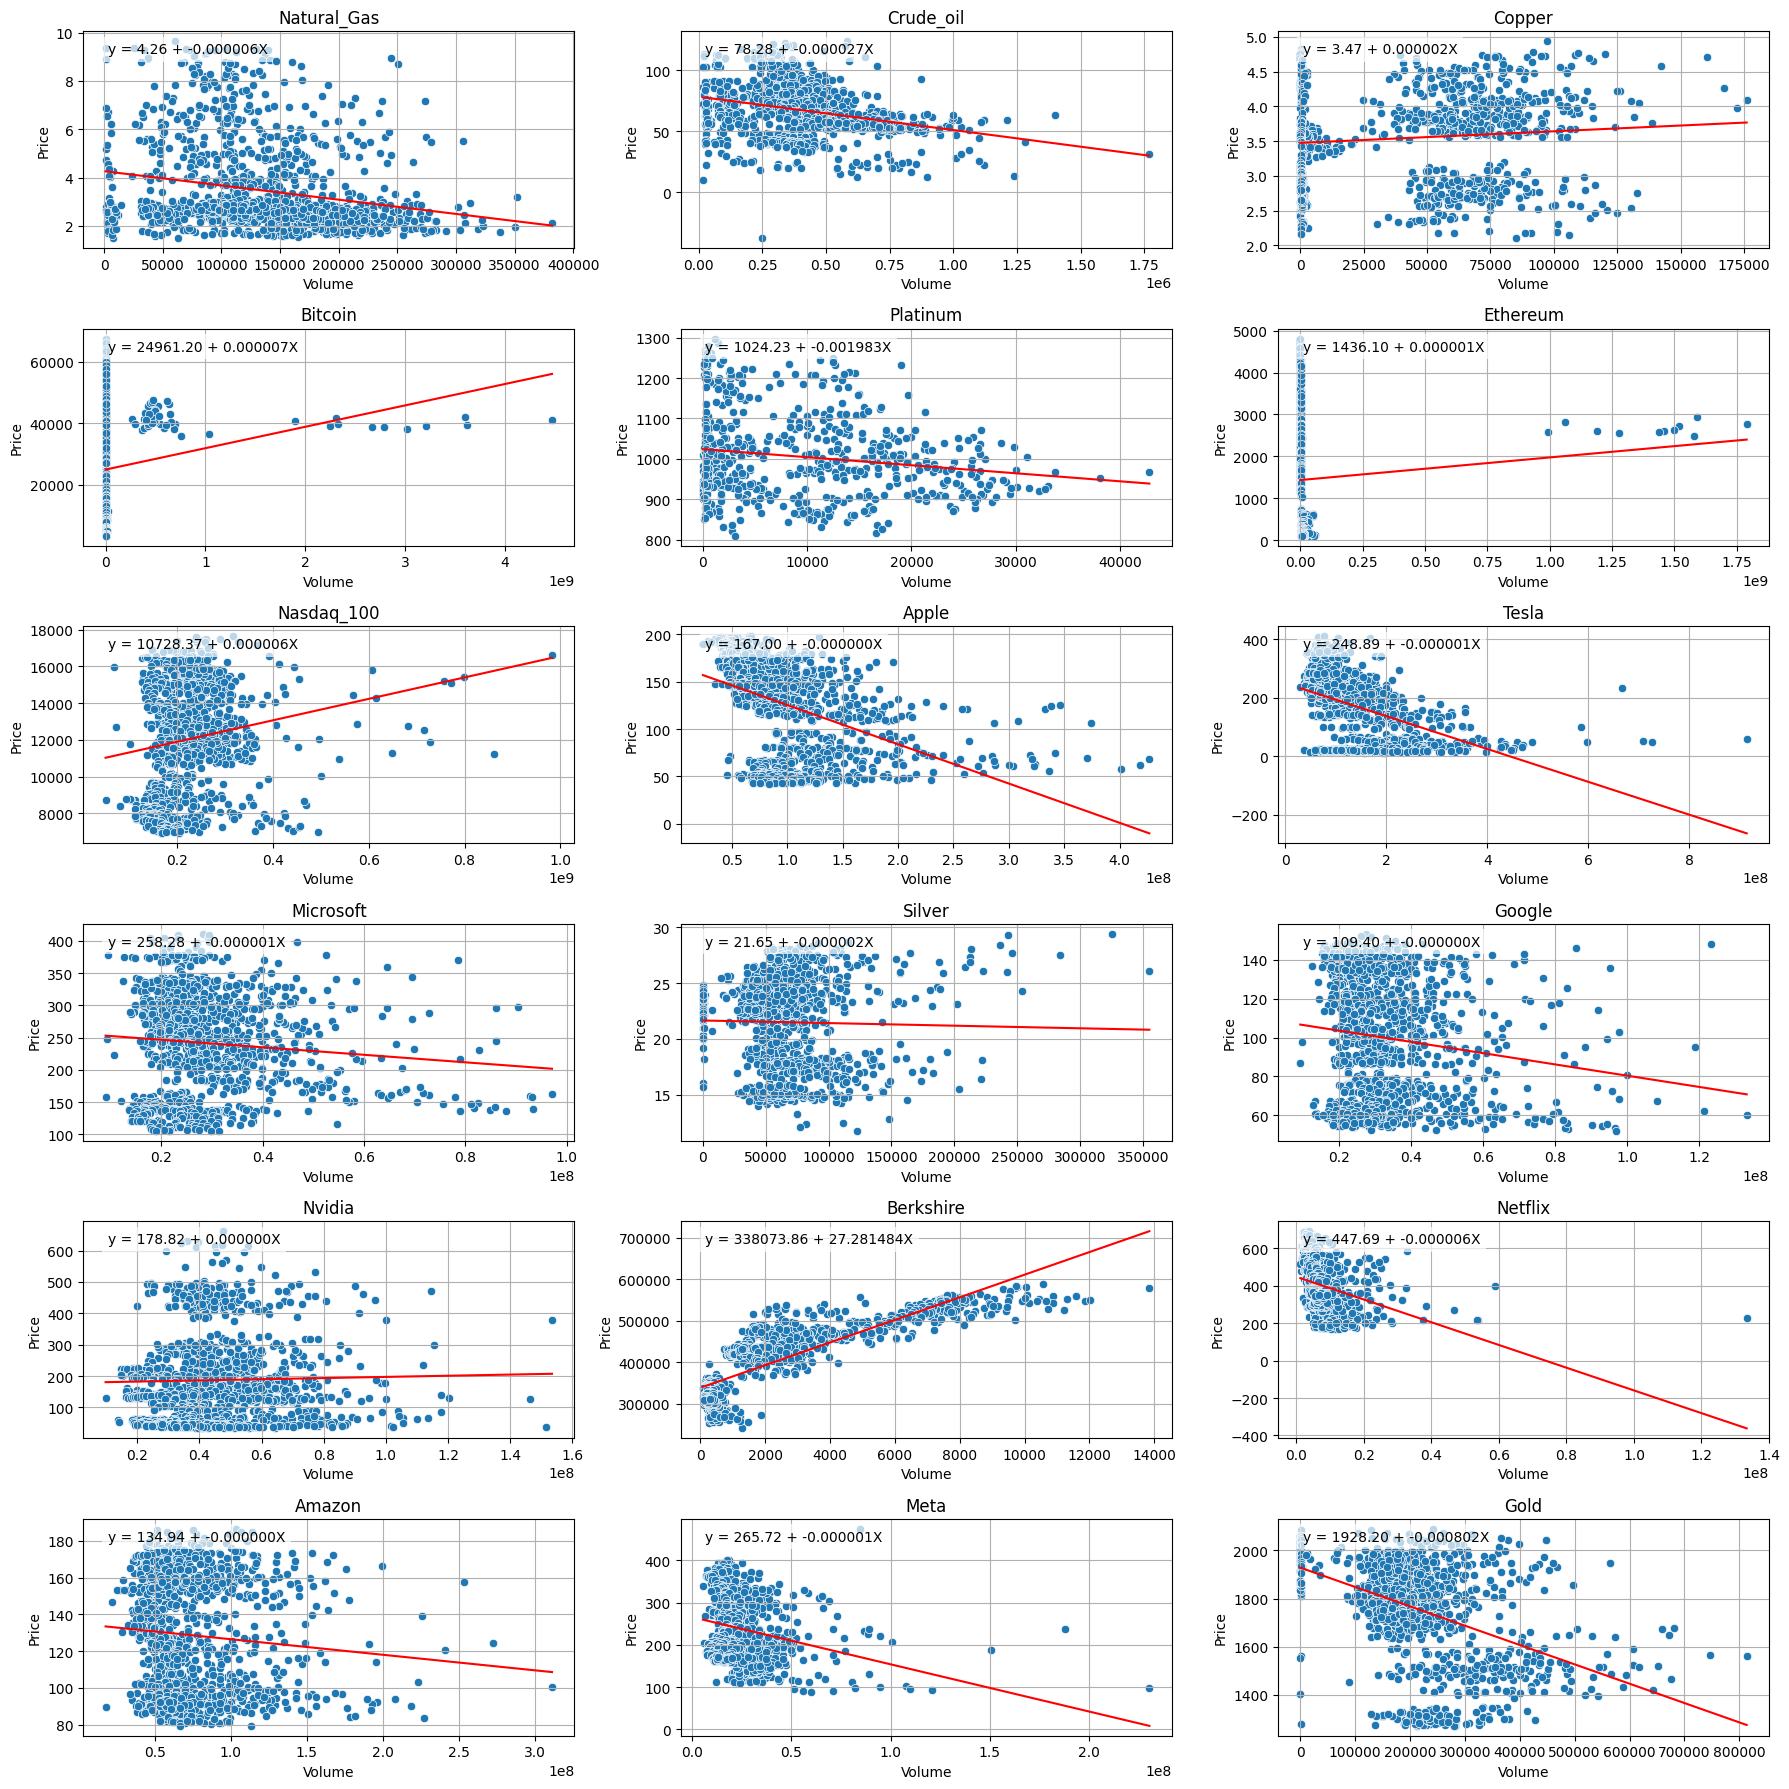

In [129]:
companies = []
for col in stock_market.columns:
    if col.endswith('_Price'):
        company = col.replace('_Price', '')
        vol_col = f'{company}_Vol.'
        if vol_col in stock_market.columns:
            companies.append(company)

n = len(companies)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3 * nrows))
axes = np.array(axes).flatten()

for i, company in enumerate(companies):
    stock_market.pipe(
        plot_company_regression,
        company=company,
        ax=axes[i]
    )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Итоговый балл за домашнее задание = набранный балл / 2**

